In [7]:
import pandas as pd
from go_ml.train_utils import get_enzyme_df, enzyme_iterator
import transformers
import matplotlib.pyplot as plt
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')

enzyme_df = get_enzyme_df()
enzyme_l = list(enzyme_iterator(enzyme_df, tokenizer))
test_prot = enzyme_l[12]

In [8]:
print(test_prot['seq'])
print(test_prot['annot_ind'])
print(test_prot['go_ind'])

MTIRRPEDFKHYEVQLPDVKIHYVREGAGPTLLLLHGWPGFWWEWSKVIGPLAEHYDVIVPDLRGFGDSEKPDLNDLSKYSLDKAADDQAALLDALGIEKAYVVGHDFAAIVLHKFIRKYSDRVIKAAIFDPIQPDFGPVYFGLGHVHESWYSQFHQLDMAVEVVGSSREVCKKYFKHFFDHWSYRDELLTEEELEVHVDNCMKPDNIHGGFNYYRANIRPDAALWTDLDHTMSDLPVTMIWGLGDTCVPYAPLIEFVPKYYSNYTMETIEDCGHFLMVEKPEIAIDRIKTAFR
[38, 107, 108, 152, 215, 246, 275]
3226


In [9]:
aa_str = 'LAGVSERTIDPKQNFYMHWC'
aa_ind = [tokenizer.get_vocab()[c] for c in aa_str]
print(aa_ind)

[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [3]:
#Load fine-tuned GO model
import torch
device = torch.device('cuda:0')
from go_ml.models.bert_finetune import BERTFinetune
checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
# with open(f"{checkpoint_dir}/esm_finetune_hparams.pkl", "rb") as f:
#     hparams = pickle.load(f)
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune-v1.ckpt", map_location=device)
model.eval()
print("Model loaded")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded


In [14]:
annot_ind = test_prot['annot_ind']
nh_ind = [121, 231, 250, 267, 280, 300]
eval_ind = annot_ind + nh_ind
eval_ind = list(range(100, 1+len(test_prot['seq'])))
aa_str = 'LAGVSERTIDPKQNFYMHWC'
aa_ind = [tokenizer.get_vocab()[c] for c in aa_str]
eval_dict = {}
with torch.no_grad():
    aa_ind = torch.tensor(aa_ind, device=device)
    seq_ind, mask =  torch.tensor(test_prot['seq_ind']).to(device), torch.BoolTensor(test_prot['mask']).to(device)
    base_batch_seq = torch.tile(seq_ind, (aa_ind.shape[0], 1))
    batch_mask = torch.tile(mask, (aa_ind.shape[0], 1))
    print(batch_mask.shape)
    for res_ind in eval_ind:
        print(f'Eval: {res_ind}')
        batch_seq = base_batch_seq.clone()
        batch_seq[:, res_ind] = aa_ind
        logits = model.forward(batch_seq, mask)
        eval_dict[res_ind] = logits.cpu().numpy()

torch.Size([20, 1024])
Eval: 100
Eval: 101
Eval: 102
Eval: 103
Eval: 104
Eval: 105
Eval: 106
Eval: 107
Eval: 108
Eval: 109
Eval: 110
Eval: 111
Eval: 112
Eval: 113
Eval: 114
Eval: 115
Eval: 116
Eval: 117
Eval: 118
Eval: 119
Eval: 120
Eval: 121
Eval: 122
Eval: 123
Eval: 124
Eval: 125
Eval: 126
Eval: 127
Eval: 128
Eval: 129
Eval: 130
Eval: 131
Eval: 132
Eval: 133
Eval: 134
Eval: 135
Eval: 136
Eval: 137
Eval: 138
Eval: 139
Eval: 140
Eval: 141
Eval: 142
Eval: 143
Eval: 144
Eval: 145
Eval: 146
Eval: 147
Eval: 148
Eval: 149
Eval: 150
Eval: 151
Eval: 152
Eval: 153
Eval: 154
Eval: 155
Eval: 156
Eval: 157
Eval: 158
Eval: 159
Eval: 160
Eval: 161
Eval: 162
Eval: 163
Eval: 164
Eval: 165
Eval: 166
Eval: 167
Eval: 168
Eval: 169
Eval: 170
Eval: 171
Eval: 172
Eval: 173
Eval: 174
Eval: 175
Eval: 176
Eval: 177
Eval: 178
Eval: 179
Eval: 180
Eval: 181
Eval: 182
Eval: 183
Eval: 184
Eval: 185
Eval: 186
Eval: 187
Eval: 188
Eval: 189
Eval: 190
Eval: 191
Eval: 192
Eval: 193
Eval: 194
Eval: 195
Eval: 196
Eval: 1

In [16]:
print(eval_dict[120][:, 3226])

[-3.4523911 -3.527062  -3.4932542 -3.4919958 -3.479353  -3.5714977
 -3.559719  -3.5383434 -3.4512405 -3.6418433 -3.4570122 -3.5253785
 -3.5259566 -3.5768647 -3.3861074 -3.3691678 -3.4916084 -3.5050838
 -3.4145637 -3.4366817]


In [17]:
import pandas as pd
import numpy as np

aa_str = 'LAGVSERTIDPKQNFYMHWC'
def pssm_to_dataframe(pssm, aa_str):
	sequence_length = pssm.shape[0]
	idx = [str(i) for i in np.arange(1, sequence_length + 1)]
	df = pd.DataFrame(pssm, index=idx, columns=list(aa_str))
	df = df.stack().reset_index()
	df.columns = ['Position', 'Amino Acid', 'Logit']
	return df

def eval_dict_to_df(eval_dict, aa_str, go_ind):
	idx = []
	aa = []
	logit = []
	for res_ind, logits in eval_dict.items():
		idx.extend([res_ind]*len(aa_str))
		aa.extend(list(aa_str))
		logit.extend(logits[:, go_ind])
		df = pd.DataFrame({'Position': idx, 'Amino Acid': aa, 'Logit': logit})
	return df

df = eval_dict_to_df(eval_dict, aa_str, 15)

# sequence = test_prot['seq']
# mutem = torch.zeros(len(sequence), len(aa_str))
# for i in range(1, len(sequence)+1):
#     mutem[i-1, :] = eval_dict[i][:, 25]
# mutem = mutem.numpy()


In [19]:
import bokeh.plotting
bokeh.io.output_notebook()
from bokeh.models import BasicTicker, PrintfTickFormatter
from bokeh.palettes import viridis, RdBu
from bokeh.transform import linear_cmap
from bokeh.plotting import figure, show

sequence = test_prot['seq']
num_colors = 256  # You can adjust this number
palette = viridis(256)

TOOLS = "hover,save,pan,box_zoom,reset,wheel_zoom"
p = figure(title="CONSERVATION",
           x_range=[str(x) for x in range(1,len(sequence)+1)],
           y_range=list(aa_str)[::-1],
           width=900, height=400,
           tools=TOOLS, toolbar_location='below',
           tooltips=[('Position', '@Position'), ('Amino Acid', '@{Amino Acid}'), ('Logit', '@Logit')])

r = p.rect(x="Position", y="Amino Acid", width=1, height=1, source=df,
           fill_color=linear_cmap('Logit', palette, low=df['Logit'].min(), high=df['Logit'].max()),
           line_color=None)
p.xaxis.visible = False
show(p)


Loading BokehJS ...

In [20]:
print(annot_ind)

[38, 107, 108, 152, 215, 246, 275]


In [27]:

TOOLS = "hover,save,pan,box_zoom,reset,wheel_zoom"
p = figure(title="CONSERVATION",
           x_range=[str(x) for x in range(1,len(sequence)+1)],
           y_range=list(aa_str)[::-1],
           width=900, height=400,
           tools=TOOLS, toolbar_location='below',
           tooltips=[('Position', '@Position'), ('Amino Acid', '@{Amino Acid}'), ('Logit', '@Logit')])

r = p.rect(x="Position", y="Amino Acid", width=1, height=1, source=df,
           fill_color=linear_cmap('Logit', palette, low=mutem.min(), high=mutem.max()),
           line_color=None)
p.xaxis.visible = False  # Hide the x-axis
show(p)

Loading BokehJS ...

In [8]:
for res_ind, logits in eval_dict.items():
    print(res_ind, torch.var(logits[:, 205]))

249 tensor(0.0414, device='cuda:0')
268 tensor(0.0082, device='cuda:0')
121 tensor(0.0026, device='cuda:0')
231 tensor(0.0012, device='cuda:0')
250 tensor(0.0781, device='cuda:0')
267 tensor(0.0032, device='cuda:0')
280 tensor(0.0019, device='cuda:0')
300 tensor(0.0015, device='cuda:0')


In [14]:
#Eval residue pairs
with torch.no_grad():
    aa_ind = torch.tensor(aa_ind, device=device)
    seq_ind, mask =  torch.tensor(test_prot['seq_ind']).to(device), torch.BoolTensor(test_prot['mask']).to(device)
    base_batch_seq = torch.tile(seq_ind, (aa_ind.shape[0], 1))
    batch_mask = torch.tile(mask, (aa_ind.shape[0], 1))
    print(batch_mask.shape)
    for i in range(len(eval_ind)):
        for j in range(i+1, len(eval_ind)):
            r1_ind, r2_ind = eval_ind[i], eval_ind[j]
            for r_val in aa_ind:
                print(f'Eval: {r1_ind} -> {r2_ind}, R1-val: {r_val}')
                batch_seq = base_batch_seq.clone()
                batch_seq[:, r1_ind] = r_val
                batch_seq[:, r2_ind] = aa_ind
                logits = model.forward(batch_seq, mask)
                eval_dict[(r1_ind, r2_ind, r_val)] = logits

/tmp/ipykernel_1328865/455664784.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  aa_ind = torch.tensor(aa_ind, device=device)


torch.Size([20, 1024])
Eval: 249 -> 268, R1-val: 4
Eval: 249 -> 268, R1-val: 5
Eval: 249 -> 268, R1-val: 6
Eval: 249 -> 268, R1-val: 7
Eval: 249 -> 268, R1-val: 8
Eval: 249 -> 268, R1-val: 9
Eval: 249 -> 268, R1-val: 10
Eval: 249 -> 268, R1-val: 11
Eval: 249 -> 268, R1-val: 12
Eval: 249 -> 268, R1-val: 13
Eval: 249 -> 268, R1-val: 14
Eval: 249 -> 268, R1-val: 15
Eval: 249 -> 268, R1-val: 16
Eval: 249 -> 268, R1-val: 17
Eval: 249 -> 268, R1-val: 18
Eval: 249 -> 268, R1-val: 19
Eval: 249 -> 268, R1-val: 20
Eval: 249 -> 268, R1-val: 21
Eval: 249 -> 268, R1-val: 22
Eval: 249 -> 268, R1-val: 23
Eval: 249 -> 121, R1-val: 4
Eval: 249 -> 121, R1-val: 5
Eval: 249 -> 121, R1-val: 6
Eval: 249 -> 121, R1-val: 7
Eval: 249 -> 121, R1-val: 8
Eval: 249 -> 121, R1-val: 9
Eval: 249 -> 121, R1-val: 10
Eval: 249 -> 121, R1-val: 11
Eval: 249 -> 121, R1-val: 12
Eval: 249 -> 121, R1-val: 13
Eval: 249 -> 121, R1-val: 14
Eval: 249 -> 121, R1-val: 15
Eval: 249 -> 121, R1-val: 16
Eval: 249 -> 121, R1-val: 17
Eva

In [22]:
eval_dict.keys()
ueval_dict = {}
for k, logits in eval_dict.items():
    if(isinstance(k, tuple)):
        r1_ind, r2_ind, r1_val = k
        ueval_dict[(r1_ind, r2_ind, r1_val.cpu().item())] = logits
eval_dict = ueval_dict

In [40]:
# r1_ind, r2_ind = tuple(annot_ind)
r1_ind, r2_ind = 121, 280
logit_l = []
for r1_val in aa_ind:
    logit_l.append(eval_dict[(r1_ind, r2_ind, r1_val.cpu().item())])
nh_logit_mat = torch.stack(logit_l, dim=0).cpu()

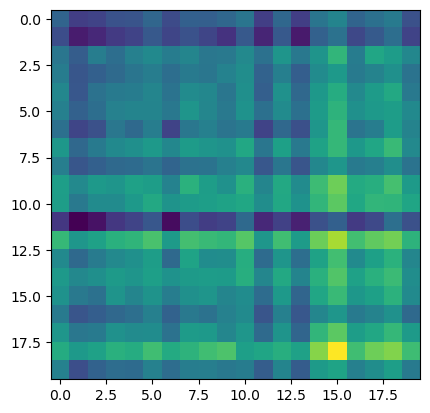

In [47]:
plt.imshow(logit_mat[:, :, 805])

In [1]:
plt.imshow(nh_logit_mat[:, :, 805])

NameError: name 'plt' is not defined